# 03 &mdash; A Priori Forecastability

Before fitting any model, this notebook asks a blunt question:
*how forecastable is this series, in theory?* The notebook is organized
in two parts. **§§2&ndash;5 are the standard finance-econometrics
battery** &mdash; stationarity (ADF / KPSS / Phillips-Perron), return
autocorrelation (Ljung-Box), the Lo-MacKinlay variance ratio, and
the Hurst exponent with Lo's modified R/S correction. These are the
canonical tests of weak-form market efficiency. **§§6&ndash;9 are
exploratory diagnostics** drawn from the nonlinear-dynamics and
signal-processing literatures (spectral predictability, permutation
entropy, the Rosenstein Lyapunov exponent with a shuffled-return
surrogate null). Both halves converge on the same answer: coffee
futures behave as a near-random walk.

## Why this notebook exists

If the series had exploitable structure, we'd expect complex models to
beat naive baselines. The a priori metrics let us form an expectation
*before* seeing any forecast results &mdash; which is methodologically
important, because it turns the benchmark from "a fishing expedition"
into a hypothesis test of whether any model can extract what the
diagnostics say isn't there.

## 1. Setup

In [1]:
import sys
from pathlib import Path

# Make `coffee_forecast` importable whether or not `pip install -e .`
# is in effect for this kernel. No-op when the package is already on
# sys.path (e.g. via the editable install); falls back to inserting
# the repo root so the notebook also runs from a fresh clone.
try:
    import coffee_forecast  # noqa: F401
except ModuleNotFoundError:
    sys.path.insert(0, str(Path.cwd().parent))

import matplotlib.pyplot as plt
import numpy as np

from coffee_forecast import (
    load_coffee_data,
    calculate_spectral_predictability,
    calculate_permutation_entropy,
    calculate_hurst_exponent,
)
from coffee_forecast.config import FIG_DIR

FIG_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
df = load_coffee_data()
prices = df["y"].values.astype(float)
log_returns = np.diff(np.log(prices))

print(
    f"Loaded {len(df)} trading days ({df['ds'].min().date()} → {df['ds'].max().date()})"
)
print(
    f"  prices:      {len(prices)} observations, "
    f"min={prices.min():.1f}, max={prices.max():.1f}"
)
print(
    f"  log-returns: {len(log_returns)} observations, "
    f"mean={log_returns.mean():+.5f}, std={log_returns.std():.4f}"
)

Loaded 8104 trading days (1994-01-03 → 2026-01-30)
  prices:      8104 observations, min=41.5, max=438.9
  log-returns: 8103 observations, mean=+0.00019, std=0.0237


## 2. Stationarity: prices vs. log-returns

Before any of the diagnostics that follow, we need to know which
representation each test should run on. Several diagnostics
(variance ratio, Hurst + R/S, the Lyapunov surrogate's
reconstruction) are defined only for stationary series and so use
log-returns; others (spectral $\Omega$, permutation entropy) we run
on both representations to expose the contrast. We start by
verifying the stationarity status of each with an Augmented
Dickey-Fuller test.

In [3]:
from statsmodels.tsa.stattools import adfuller

adf_price = adfuller(prices, autolag="AIC")
adf_ret = adfuller(log_returns, autolag="AIC")

print("Augmented Dickey-Fuller Test:")
print(
    f"  Prices      : ADF = {adf_price[0]:+7.3f},  p = {adf_price[1]:6.3f}  "
    f"→ {'Non-stationary' if adf_price[1] > 0.05 else 'Stationary'}"
)
print(
    f"  Log-returns : ADF = {adf_ret[0]:+7.3f},  p = {adf_ret[1]:.2e}  "
    f"→ {'Non-stationary' if adf_ret[1] > 0.05 else 'Stationary'}"
)

Augmented Dickey-Fuller Test:
  Prices      : ADF =  -1.451,  p =  0.557  → Non-stationary
  Log-returns : ADF = -20.879,  p = 0.00e+00  → Stationary


### 2b. Confirmatory unit-root tests: KPSS and Phillips-Perron

ADF is the standard first-pass test but has known weaknesses: low power
against persistent stationary alternatives, and it assumes homoskedastic
errors (which §4 of notebook 04 will show coffee returns violate). Two
complementary tests sharpen the conclusion:

- **KPSS** (Kwiatkowski et al. 1992) *reverses* the null: H0 is
  stationarity, rejection means non-stationarity. Pairing it with ADF
  creates a confirmatory design &mdash; agreement across both tests is
  stronger evidence than either alone.
- **Phillips-Perron** (1988) has the same null as ADF but uses a
  non-parametric correction for heteroskedasticity and serial
  correlation in the errors. Robust to the volatility clustering in
  coffee returns.

In [4]:
from statsmodels.tsa.stattools import kpss
from arch.unitroot import PhillipsPerron

# KPSS on prices (H0: stationary)
kpss_price_stat, kpss_price_p, kpss_price_lag, kpss_price_crit = kpss(
    prices, regression="c", nlags="auto"
)
# KPSS on log-returns
kpss_ret_stat, kpss_ret_p, kpss_ret_lag, kpss_ret_crit = kpss(
    log_returns, regression="c", nlags="auto"
)

# Phillips-Perron on prices (H0: unit root, same direction as ADF)
pp_price = PhillipsPerron(prices)
pp_ret = PhillipsPerron(log_returns)

print("KPSS Test  (H0: stationary  \u2192  reject means NON-stationary)")
print(
    f"  Prices      : stat = {kpss_price_stat:+7.3f},  p = {kpss_price_p:.3f}  "
    f"\u2192 {'Reject (non-stationary)' if kpss_price_p < 0.05 else 'Fail to reject (stationary)'}"
)
print(
    f"  Log-returns : stat = {kpss_ret_stat:+7.3f},  p = {kpss_ret_p:.3f}  "
    f"\u2192 {'Reject (non-stationary)' if kpss_ret_p < 0.05 else 'Fail to reject (stationary)'}"
)
print()
print("Phillips-Perron Test  (H0: unit root  \u2192  reject means stationary)")
print(
    f"  Prices      : stat = {pp_price.stat:+7.3f},  p = {pp_price.pvalue:.3f}  "
    f"\u2192 {'Stationary' if pp_price.pvalue < 0.05 else 'Non-stationary'}"
)
print(
    f"  Log-returns : stat = {pp_ret.stat:+7.3f},  p = {pp_ret.pvalue:.3f}  "
    f"\u2192 {'Stationary' if pp_ret.pvalue < 0.05 else 'Non-stationary'}"
)

KPSS Test  (H0: stationary  →  reject means NON-stationary)
  Prices      : stat =  +3.960,  p = 0.010  → Reject (non-stationary)
  Log-returns : stat =  +0.055,  p = 0.100  → Fail to reject (stationary)

Phillips-Perron Test  (H0: unit root  →  reject means stationary)
  Prices      : stat =  -1.726,  p = 0.418  → Non-stationary
  Log-returns : stat = -91.701,  p = 0.000  → Stationary


/var/folders/bb/jyf3hcfj6wn4256f5gz4c_7w0000gn/T/ipykernel_9481/500230482.py:5: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_price_stat, kpss_price_p, kpss_price_lag, kpss_price_crit = kpss(
/var/folders/bb/jyf3hcfj6wn4256f5gz4c_7w0000gn/T/ipykernel_9481/500230482.py:9: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_ret_stat, kpss_ret_p, kpss_ret_lag, kpss_ret_crit = kpss(


> All three tests agree. ADF and Phillips-Perron fail to reject the
> unit-root null on prices (p > 0.05) and strongly reject it on
> log-returns. KPSS, with the reversed null, rejects stationarity on
> prices and fails to reject it on log-returns. The confirmatory design
> eliminates the classic "low-power ADF" critique: when ADF and KPSS
> agree, we have much stronger evidence than either in isolation. The
> Phillips-Perron result adds robustness to the heteroskedasticity that
> §4 of notebook 04 will confirm is present in the error process.

The `InterpolationWarning` in the KPSS output is benign: the test
statistic is outside the lookup table, so the printed p-value is a
*bound* (the actual p-value is more extreme, in the direction that
strengthens rather than weakens the conclusion).

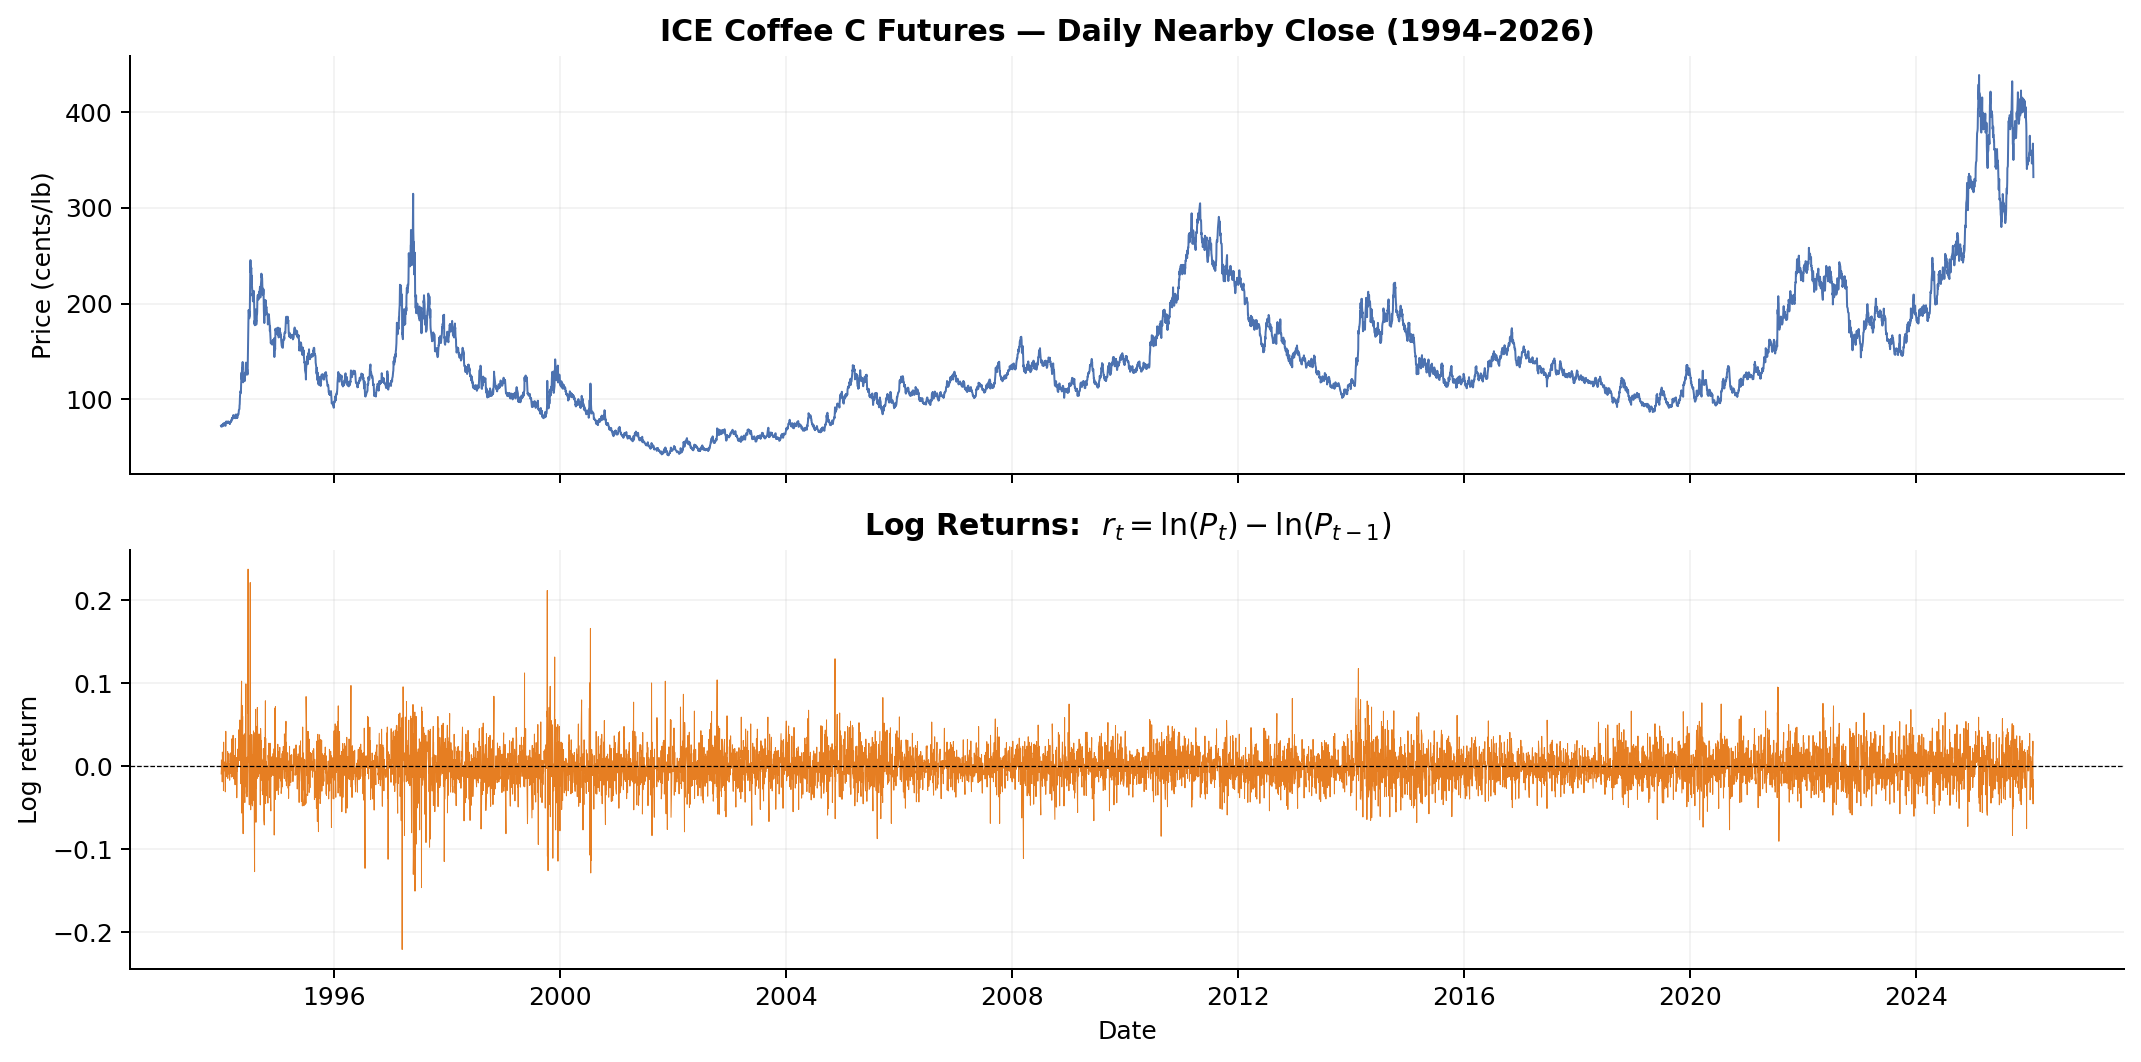

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True, dpi=180)

axes[0].plot(df["ds"], prices, linewidth=0.8, color="#4C72B0")
axes[0].set_title(
    "ICE Coffee C Futures — Daily Nearby Close (1994–2026)",
    fontsize=12,
    weight="semibold",
)
axes[0].set_ylabel("Price (cents/lb)")
axes[0].grid(alpha=0.15)
axes[0].spines["top"].set_visible(False)
axes[0].spines["right"].set_visible(False)

axes[1].plot(df["ds"].iloc[1:], log_returns, linewidth=0.4, color="#E67E22")
axes[1].axhline(0, color="black", lw=0.5, ls="--")
axes[1].set_title(
    r"Log Returns:  $r_t = \ln(P_t) - \ln(P_{t-1})$", fontsize=12, weight="semibold"
)
axes[1].set_ylabel("Log return")
axes[1].set_xlabel("Date")
axes[1].grid(alpha=0.15)
axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)

fig.tight_layout()
fig.savefig(FIG_DIR / "prices_vs_logreturns.png", dpi=300, bbox_inches="tight")
plt.show()

The ADF result is exactly what you'd expect of a commodity price:
prices are non-stationary (they wander), log-returns are stationary
(they hover around zero with roughly constant variance &mdash; the
well-known volatility clustering notwithstanding).

## 3. Return autocorrelation: Ljung-Box test

Under weak-form market efficiency, daily returns should not be
linearly predictable from their own past. The Ljung-Box test checks
the joint null that all autocorrelations up to lag $L$ are zero,
with statistic $Q(L) = T(T+2) \sum_{k=1}^{L} \hat\rho_k^2 / (T-k)$
asymptotically $\chi^2_L$ under $H_0$. We test on log-returns at
$L = 10$ (about two trading weeks) and $L = 20$ (a trading month).

In [6]:
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.stattools import acf

lb = acorr_ljungbox(log_returns, lags=[10, 20], return_df=True)
print("Ljung-Box on log-returns:")
print(
    f"  L = 10:  Q = {lb.iloc[0]['lb_stat']:>7.2f},  p = {lb.iloc[0]['lb_pvalue']:.4f}"
)
print(
    f"  L = 20:  Q = {lb.iloc[1]['lb_stat']:>7.2f},  p = {lb.iloc[1]['lb_pvalue']:.4f}"
)

# Magnitude of the autocorrelations underneath the rejection.
rho = acf(log_returns, nlags=20, fft=False)[1:]  # drop lag 0
mean_abs_rho = float(np.mean(np.abs(rho)))
max_abs_rho = float(np.max(np.abs(rho)))
print(f"\n|\u03c1(k)| averaged over lags 1\u201320:  {mean_abs_rho:.4f}")
print(f"|\u03c1(k)| max over lags 1\u201320:       {max_abs_rho:.4f}")

Ljung-Box on log-returns:
  L = 10:  Q =   24.53,  p = 0.0063
  L = 20:  Q =   39.31,  p = 0.0061

|ρ(k)| averaged over lags 1–20:  0.0129
|ρ(k)| max over lags 1–20:       0.0396


Ljung-Box formally rejects the joint zero-autocorrelation null at
both lag windows ($p \approx 0.006$). The rejection is real but
needs context: with $T = 8{,}103$ observations, even tiny
autocorrelations are detectable, and the average
$|\hat\rho(k)|$ over lags 1\u201320 is on the order of $10^{-2}$.
This is the textbook stylized fact for liquid financial returns
(Cont 2001): linear return autocorrelations are *statistically*
non-zero at large sample sizes but *economically negligible*,
too small to exploit through trading rules or point-forecast
models. The heteroskedasticity-robust variance-ratio test in &sect;4
confirms the practical reading &mdash; random-walk dynamics are
not rejected at any horizon &mdash; because the heteroskedasticity
VR is robust to (and LB is not) explains most of the detectable
serial structure.

The companion ACF visualization &mdash; returns vs. squared returns
side-by-side &mdash; appears in &sect;4 of notebook 04, where the
contrast (returns nearly flat, squared returns persistent) is what
motivates the GARCH model.

## 4. Lo-MacKinlay Variance Ratio Test

Under the random-walk null, the variance of $q$-period returns equals $q$
times the variance of one-period returns, so $\mathrm{VR}(q) = \mathrm{Var}(r_t^{(q)}) / [q \cdot \mathrm{Var}(r_t)]$ should equal 1 at every horizon. Deviations are direct
evidence against the random-walk hypothesis. We use the heteroskedasticity-
robust $z$-statistic of Lo and MacKinlay (1988), which handles the
volatility clustering coffee returns exhibit.

Unlike ADF (which tests for a unit root in levels) or Hurst (which tests
for long memory), the variance-ratio test is a direct test of the
random-walk hypothesis and is the canonical test in the forecasting
literature going back to Meese-Rogoff.

In [7]:
from scipy import stats as _stats


def variance_ratio_test(x, q):
    """Lo-MacKinlay variance ratio with heteroskedasticity-robust z-stat."""
    x = np.asarray(x, dtype=float)
    T = len(x)
    mu = x.mean()
    var1 = np.sum((x - mu) ** 2) / (T - 1)
    xq = np.convolve(x, np.ones(q), mode="valid")
    m = (T - q + 1) * (1 - q / T)
    varq = np.sum((xq - q * mu) ** 2) / m
    VR = varq / (q * var1)
    deltas = []
    for j in range(1, q):
        num = np.sum(((x[j:] - mu) ** 2) * ((x[:-j] - mu) ** 2))
        den = (np.sum((x - mu) ** 2)) ** 2 / T
        deltas.append(num / den)
    theta = sum(((2 * (q - j) / q) ** 2) * d for j, d in enumerate(deltas, start=1))
    z = (VR - 1) / np.sqrt(theta / T)
    p = 2 * (1 - _stats.norm.cdf(abs(z)))
    return VR, z, p


print(f"  {'q':>4} | {'VR(q)':>7} | {'z (het-robust)':>15} | {'p-value':>8}")
print(f"  {'-' * 4}-+-{'-' * 7}-+-{'-' * 15}-+-{'-' * 8}")
for q in [2, 4, 8, 16, 32]:
    VR, z, p = variance_ratio_test(log_returns, q)
    print(f"  {q:>4} | {VR:>7.4f} | {z:>15.3f} | {p:>8.4f}")

     q |   VR(q) |  z (het-robust) |  p-value
  -----+---------+-----------------+---------
     2 |  0.9863 |          -0.837 |   0.4028
     4 |  0.9786 |          -0.707 |   0.4793
     8 |  0.9472 |          -1.136 |   0.2560
    16 |  0.9409 |          -0.884 |   0.3766
    32 |  0.8517 |          -1.604 |   0.1088


> VR(q) is within rounding distance of 1 at every horizon and no
> z-statistic reaches conventional significance. We fail to reject the
> random-walk null at q = 2, 4, 8, 16, and 32 days. This is the
> strongest direct evidence in the a priori battery that the series is
> consistent with a random walk.

## 5. Hurst exponent + Lo's modified R/S

The Hurst exponent $H$ is estimated from the log-log slope of the
rescaled range $(R/S)_n$ vs. window size $n$:

$$\mathbb{E}[(R/S)_n] \sim c \cdot n^H$$

- $H = 0.5$ : random walk, no exploitable memory
- $H > 0.5$ : persistent / trending
- $H < 0.5$ : anti-persistent / mean-reverting

Classical $H$ is biased upward by short-range autocorrelation, so we
also compute Lo's (1991) modified R/S statistic $V_n$, which uses a
Bartlett-kernel HAC adjustment. Under $H_0$ of no long memory,
$V_n \in [0.809, 1.862]$ at the 95% level.

**Why returns, not prices?** $R/S$ is defined for stationary series.
Computing it on the non-stationary price level would give a misleading
$H \approx 1$ regardless of the underlying dynamics. Log-returns are
the standard, theoretically correct representation.

In [8]:
h, v_n, lo_result = calculate_hurst_exponent(prices)

lo_lower, lo_upper = 0.809, 1.862
verdict = (
    f"FAIL TO REJECT H0 (V_n = {v_n:.3f} inside [{lo_lower}, {lo_upper}])\n"
    f"  → No statistically significant long memory at 95%; "
    f"H ≈ 0.5 likely reflects short-range autocorrelation bias"
    if lo_result == "fail to reject"
    else f"REJECT H0 (V_n = {v_n:.3f} outside [{lo_lower}, {lo_upper}])\n"
    f"  → Statistically significant long memory detected"
)

print(f"Hurst exponent  H   = {h:.4f}")
print(f"Lo's V_n            = {v_n:.4f}")
print(f"  {verdict}")

Hurst exponent  H   = 0.5353
Lo's V_n            = 1.1374
  FAIL TO REJECT H0 (V_n = 1.137 inside [0.809, 1.862])
  → No statistically significant long memory at 95%; H ≈ 0.5 likely reflects short-range autocorrelation bias


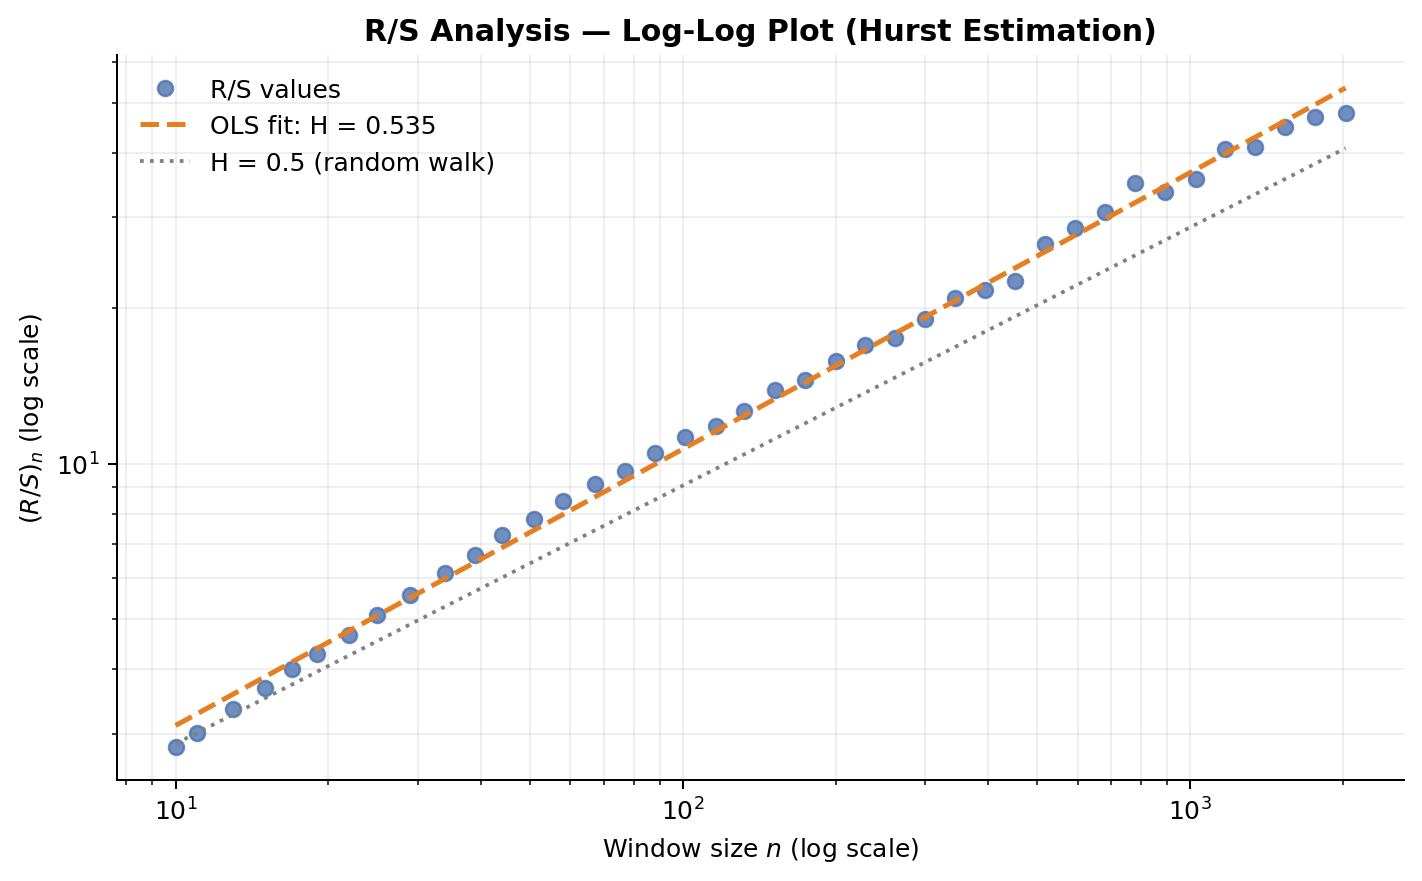

In [9]:
# Reproduce the R/S log-log plot used to estimate H.
from scipy import stats as sp_stats

rets = log_returns
T = len(rets)
n_max = T // 4
window_sizes = np.unique(np.logspace(np.log10(10), np.log10(n_max), 40).astype(int))


def _rs(x, n):
    num = len(x) // n
    if num == 0:
        return np.nan
    vals = []
    for w in range(num):
        chunk = x[w * n : (w + 1) * n]
        e = chunk - chunk.mean()
        X = np.cumsum(e)
        R = X.max() - X.min()
        S = chunk.std(ddof=1)
        if S > 0:
            vals.append(R / S)
    return np.mean(vals) if vals else np.nan


rs_vals = np.array([_rs(rets, n) for n in window_sizes])
valid = ~np.isnan(rs_vals) & (rs_vals > 0)
slope, intercept, *_ = sp_stats.linregress(
    np.log(window_sizes[valid]), np.log(rs_vals[valid])
)

fig, ax = plt.subplots(figsize=(8, 5), dpi=180)
ax.loglog(
    window_sizes[valid],
    rs_vals[valid],
    "o",
    color="#4C72B0",
    markersize=6,
    alpha=0.8,
    label="R/S values",
)
xs_line = np.array([window_sizes[valid].min(), window_sizes[valid].max()])
ax.plot(
    xs_line,
    np.exp(intercept + slope * np.log(xs_line)),
    "--",
    color="#E67E22",
    linewidth=2,
    label=f"OLS fit: H = {slope:.3f}",
)
ax.plot(
    xs_line,
    np.exp(intercept + 0.5 * np.log(xs_line)),
    ":",
    color="gray",
    linewidth=1.5,
    label="H = 0.5 (random walk)",
)

ax.set_title(
    "R/S Analysis \u2014 Log-Log Plot (Hurst Estimation)",
    fontsize=12,
    weight="semibold",
)
ax.set_xlabel("Window size $n$ (log scale)")
ax.set_ylabel("$(R/S)_n$ (log scale)")
ax.legend(frameon=False, fontsize=10)
ax.grid(alpha=0.2, which="both")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
fig.tight_layout()
fig.savefig(FIG_DIR / "hurst_rs.png", dpi=300, bbox_inches="tight")
plt.show()

---

## Beyond the standard battery: exploratory diagnostics

The four tests above (stationarity, return autocorrelation, variance
ratio, Hurst + Lo's R/S) are the standard finance-econometrics
battery for characterizing whether a series is consistent with
weak-form market efficiency. The next four sections cover three
additional metrics drawn from the nonlinear-dynamics and
signal-processing literatures (Wang & Klee 2025; Bandt-Pompe
permutation entropy; Rosenstein's Lyapunov estimator with a
shuffled-return surrogate test). They aren't load-bearing for the
EMH conclusion &mdash; the standard battery already settles it &mdash;
but they provide independent confirmation from mathematically
different angles.

## 6. Spectral Predictability ($\Omega$)

Spectral predictability (Wang & Klee, KDD 2025) measures how much
energy is concentrated in a few dominant frequencies. A series with
strong periodic structure has a spiked PSD and a high $\Omega$; white
noise has a flat PSD and $\Omega \to 0$.

$$\Omega = 1 - \frac{H_{\text{spectral}}}{\log(N_{\text{freq}})}$$

**Adaptation for discrete series.** Wang & Klee define
$\Omega = 1 - H_{\text{spectral}} / \log(2\pi)$, treating $\log(2\pi)$
as the entropy ceiling in the continuous-time limit. That works
asymptotically but breaks for long discrete series: in our 8,104-point
sample, $\log(N_{\text{freq}}) \approx \log(4053) \approx 8.3$, which
is roughly $4.5\times$ larger than $\log(2\pi) \approx 1.84$, so
$H_{\text{spectral}}$ routinely exceeds the original denominator and
$\Omega$ falls outside $[0, 1]$. We replace the denominator with
$\log(N_{\text{freq}})$ &mdash; the actual maximum entropy for
$N_{\text{freq}}$ frequency bins, achieved by discrete white noise.
This keeps $\Omega \in [0, 1]$ at any series length and lets the 0.20
forecastability threshold from Wang & Klee transfer directly.


In [10]:
omega = calculate_spectral_predictability(prices)
omega_returns = calculate_spectral_predictability(log_returns)
print(f"Ω on prices       = {omega:.4f}")
print(f"Ω on log-returns  = {omega_returns:.4f}")

Ω on prices       = 0.6831
Ω on log-returns  = 0.0529


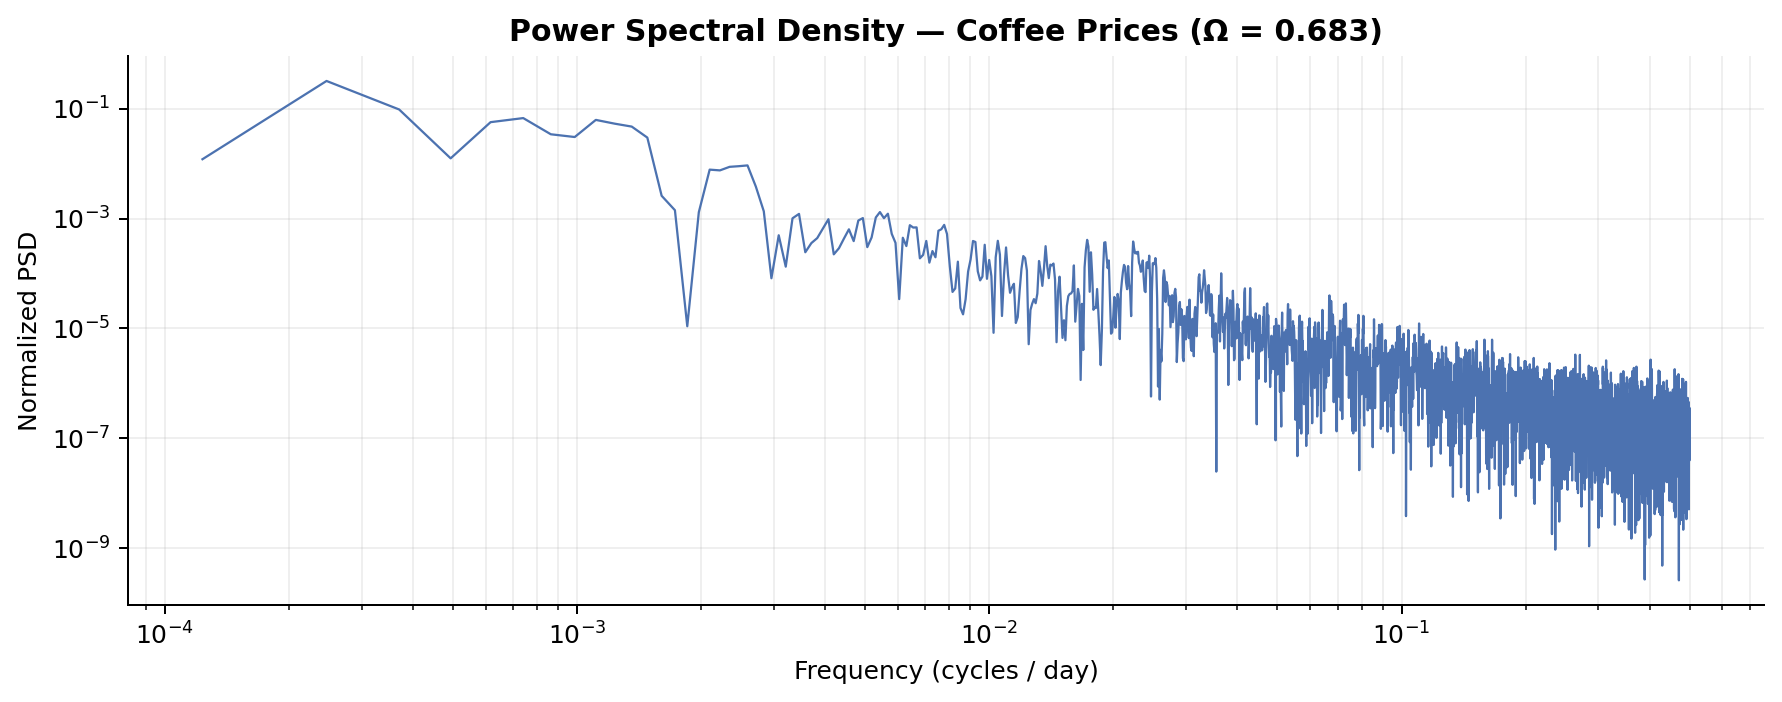

In [11]:
# Replicate the internal PSD computation so we can plot it.
from scipy.signal import detrend

detrended = detrend(prices)
windowed = detrended * np.hanning(len(detrended))
fft_vals = np.fft.rfft(windowed)
psd = np.abs(fft_vals) ** 2
psd_norm = psd / np.sum(psd)
freqs = np.fft.rfftfreq(len(detrended), d=1.0)  # cycles / day

fig, ax = plt.subplots(figsize=(10, 4), dpi=180)
ax.loglog(freqs[1:], psd_norm[1:], color="#4C72B0", linewidth=0.9)
ax.set_title(
    f"Power Spectral Density \u2014 Coffee Prices (\u03a9 = {omega:.3f})",
    fontsize=12,
    weight="semibold",
)
ax.set_xlabel("Frequency (cycles / day)")
ax.set_ylabel("Normalized PSD")
ax.grid(alpha=0.2, which="both")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
fig.tight_layout()
fig.savefig(FIG_DIR / "spectral_psd.png", dpi=300, bbox_inches="tight")
plt.show()

$\Omega \approx 0.68$ sounds high, but the shape of the PSD tells the
real story: the energy concentrates at the *lowest* frequencies with no
discrete peaks. That's the fingerprint of a non-stationary random walk
(low-frequency drift), not of exploitable periodic structure. In other
words, "structure" exists &mdash; but it's the kind that makes the series
*harder* to forecast, not easier.

> **Confirmatory: Ω on log returns.** Computed on the stationary
> representation, Ω drops sharply from 0.68 to roughly 0.05 &mdash;
> close to the white-noise floor. The contrast is itself diagnostic:
> the apparent "structure" in the price-level spectrum is the
> low-frequency drift of an I(1) process, not exploitable periodicity
> in the dynamics. Once that drift is differenced out, the spectrum
> flattens.

## 7. Permutation Entropy (PE)

Permutation entropy measures *ordinal-pattern complexity*. For
embedding order $m = 3$, we slide a window of length 3 across the
series and count the six possible rank orderings. If all six patterns
occur roughly equally often, PE $\to 1$ (maximally random). If a few
dominate, PE $\to 0$ (deterministic structure).

It's a complementary perspective to spectral predictability: the PSD
cares about *periodicities*, while PE cares about *local orderings*.
A series can fool one and not the other, so agreement is meaningful.

In [12]:
pe = calculate_permutation_entropy(prices, order=3, delay=1)
pe_returns = calculate_permutation_entropy(log_returns, order=3, delay=1)
print(f"PE on prices       = {pe:.4f}  ({pe * 100:.1f}% stochastic)")
print(f"PE on log-returns  = {pe_returns:.4f}  ({pe_returns * 100:.1f}% stochastic)")

PE on prices       = 0.9742  (97.4% stochastic)
PE on log-returns  = 0.9999  (100.0% stochastic)


97% is near the ceiling &mdash; the six ordinal patterns of length 3 are
almost uniformly distributed in the price series. There's essentially
no deterministic local structure to exploit.

> **Confirmatory: PE on log returns.** Permutation entropy on the
> differenced series remains essentially at its ceiling. Because PE
> is invariant under monotone transformations of the series,
> near-equal values on prices and returns are expected; the
> agreement rules out the possibility that the high PE on prices is
> a quirk of the non-stationary representation.

## 8. Largest Lyapunov Exponent ($\lambda$)

The Lyapunov exponent measures sensitivity to initial conditions in a
reconstructed phase space. For an embedding dimension $m$ and delay $\tau$,
nearby trajectories $x_t$ and $x'_t$ separate at an exponential rate:
$\delta(\Delta t) \approx \delta_0 \cdot \exp(\lambda \cdot \Delta t)$. A
positive $\lambda$ indicates chaotic divergence (reduced forecastability);
$\lambda \le 0$ indicates stability.

We use the Rosenstein et al. (1993) algorithm, which estimates $\lambda$
as the slope of the mean log-divergence curve over a fixed window. It
is more stable on short, noisy financial series than the alternative
Wolf et al. (1985) method, which actively renormalizes vectors and is
known to overestimate $\lambda$ on stochastic data.

Lyapunov estimation on noisy financial data is less robust than the
other diagnostics &mdash; Wang & Klee (2025) recommend at least
$100 \cdot m$ data points and caution about sparsity effects. We
report $\lambda$ on daily prices only; weekly and monthly aggregations
violate the sample-size guidance and produce unstable estimates.

In [13]:
def largest_lyapunov(x, m=3, tau=1, mean_period=10, max_t=20):
    """
    Largest Lyapunov exponent via Rosenstein et al. (1993).
    Returns the slope of the mean log-divergence curve over max_t steps.
    """
    x = np.asarray(x, dtype=float)
    N = len(x) - (m - 1) * tau
    if N <= 0:
        return np.nan
    # Build delay-embedded vectors.
    emb = np.column_stack([x[i * tau : i * tau + N] for i in range(m)])
    # For each point, find its nearest neighbor (with temporal separation).
    from scipy.spatial import cKDTree

    tree = cKDTree(emb)
    dists, idx = tree.query(emb, k=mean_period + 2)
    neighbors = np.full(N, -1, dtype=int)
    for i in range(N):
        for k in range(1, dists.shape[1]):
            if abs(idx[i, k] - i) > mean_period:
                neighbors[i] = idx[i, k]
                break
    valid = neighbors >= 0
    # Track divergence.
    log_div = []
    for dt in range(1, max_t + 1):
        pairs = [
            (i, neighbors[i])
            for i in range(N)
            if valid[i] and i + dt < N and neighbors[i] + dt < N
        ]
        if not pairs:
            log_div.append(np.nan)
            continue
        d = [np.linalg.norm(emb[i + dt] - emb[j + dt]) for i, j in pairs]
        d = [di for di in d if di > 0]
        if not d:
            log_div.append(np.nan)
            continue
        log_div.append(np.mean(np.log(d)))
    log_div = np.array(log_div)
    ts = np.arange(1, max_t + 1)
    valid_t = ~np.isnan(log_div)
    slope, *_ = _stats.linregress(ts[valid_t], log_div[valid_t])
    return float(slope)


lam = largest_lyapunov(prices, m=3, tau=1)
print(f"Largest Lyapunov exponent (prices, m=3, τ=1):  λ = {lam:+.4f}")
print("  → Raw value; surrogate-data significance test in §7b below.")


Largest Lyapunov exponent (prices, m=3, τ=1):  λ = +0.0708
  → Raw value; surrogate-data significance test in §7b below.


> A positive λ corroborates the other diagnostics: small perturbations
> amplify over time, so even a model that fits the past well will
> diverge from realized paths as the horizon grows. This is the phase-
> space counterpart to the variance-ratio and Hurst results: all three
> say the same thing about forecast reliability, from three different
> mathematical angles.

**Caveat.** The Lyapunov exponent is a *deterministic* dynamical-systems
concept, and Rosenstein's algorithm is known to return small positive
values on stochastic data through finite-sample bias alone. Without a
null distribution, λ = +0.07 by itself is not statistically
distinguishable from "stochastic divergence with no underlying chaos."
The §8b cell below addresses this with a surrogate-data test; the
synthesis in §9 reports both the raw value and the surrogate-corrected
verdict.

### 8b. Surrogate-data null for $\lambda$

To turn the raw $\lambda = +0.07$ into a hypothesis test, we generate
shuffled-return *surrogate* price series and recompute $\lambda$ on each.
Shuffling log-returns destroys all temporal structure (linear and
non-linear) while preserving the marginal distribution of returns; if
the dynamics of the original series have any deterministic structure
beyond noise, observed $\lambda$ should sit in the upper tail of the
surrogate distribution.

The null and alternative:

- $H_0$: the price dynamics have no deterministic structure beyond
  what's preserved by random reshuffling of returns.
- $H_1$: the dynamics carry deterministic information that produces a
  larger $\lambda$ than would be expected under reshuffling.

We compute one-sided p-value $P(\lambda_{\text{surr}} \geq \lambda_{\text{obs}})$
under $H_0$, with 100 surrogates (cheap; finer resolution would only
matter at borderline p-values).

Computing λ on 100 shuffled-return surrogates...
  ... 25/100 surrogates done
  ... 50/100 surrogates done
  ... 75/100 surrogates done
  ... 100/100 surrogates done

Observed λ (coffee prices):     +0.0708
Surrogate λ (mean ± std):       +0.0743 ± 0.0018
Surrogate λ range:              [+0.0682, +0.0782]

One-sided p-value  P(λ_surr ≥ λ_obs | H0):  0.970
  → FAIL TO REJECT H0: observed λ is consistent with shuffled-return null


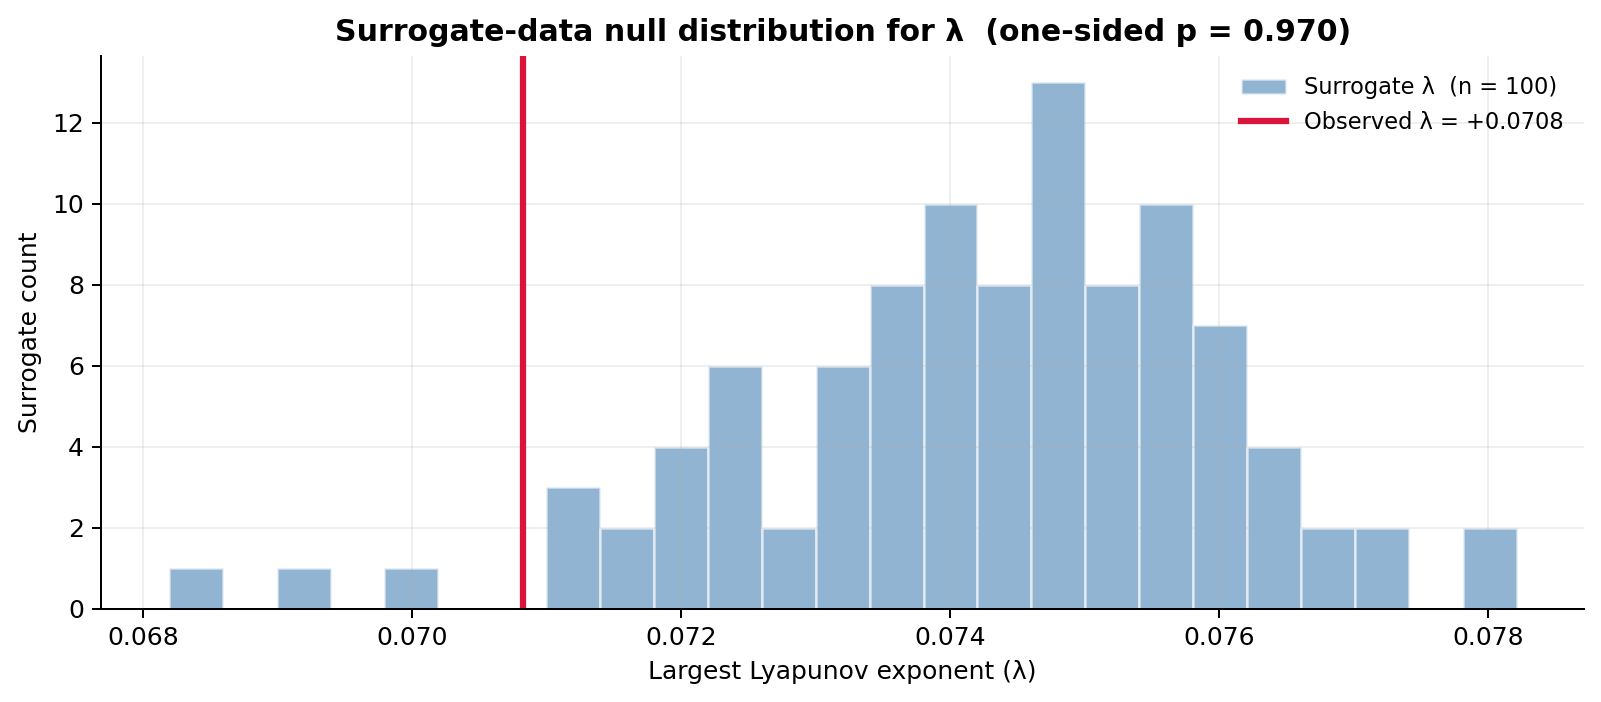

In [14]:
N_SURROGATES = 100
rng_lyap = np.random.default_rng(42)

# Shuffle log-returns and reconstruct prices via cumsum + exp.
log_ret_for_surr = np.diff(np.log(prices))
P0 = float(prices[0])

print(f"Computing λ on {N_SURROGATES} shuffled-return surrogates...")
lam_surrogates = np.zeros(N_SURROGATES)
for i in range(N_SURROGATES):
    shuffled = log_ret_for_surr.copy()
    rng_lyap.shuffle(shuffled)
    surr_prices = P0 * np.exp(np.concatenate([[0.0], np.cumsum(shuffled)]))
    lam_surrogates[i] = largest_lyapunov(surr_prices, m=3, tau=1)
    if (i + 1) % 25 == 0:
        print(f"  ... {i + 1}/{N_SURROGATES} surrogates done")

p_surrogate = float((lam_surrogates >= lam).mean())

print(f"\nObserved λ (coffee prices):     {lam:+.4f}")
print(
    f"Surrogate λ (mean ± std):       "
    f"{lam_surrogates.mean():+.4f} ± {lam_surrogates.std():.4f}"
)
print(
    f"Surrogate λ range:              "
    f"[{lam_surrogates.min():+.4f}, {lam_surrogates.max():+.4f}]"
)
print(f"\nOne-sided p-value  P(λ_surr ≥ λ_obs | H0):  {p_surrogate:.3f}")
verdict = (
    "REJECT H0: observed λ is in upper tail; some deterministic structure"
    if p_surrogate < 0.05
    else "FAIL TO REJECT H0: observed λ is consistent with shuffled-return null"
)
print(f"  → {verdict}")

# Histogram of surrogate λ with observed value marked.
fig, ax = plt.subplots(figsize=(9, 4), dpi=180)
ax.hist(
    lam_surrogates,
    bins=25,
    color="steelblue",
    alpha=0.6,
    edgecolor="white",
    label=f"Surrogate λ  (n = {N_SURROGATES})",
)
ax.axvline(
    lam,
    color="crimson",
    lw=2.5,
    label=f"Observed λ = {lam:+.4f}",
)
ax.set_title(
    f"Surrogate-data null distribution for λ  (one-sided p = {p_surrogate:.3f})",
    fontsize=12,
    weight="semibold",
)
ax.set_xlabel("Largest Lyapunov exponent (λ)")
ax.set_ylabel("Surrogate count")
ax.legend(frameon=False, fontsize=9)
ax.grid(alpha=0.2)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
fig.tight_layout()
fig.savefig(FIG_DIR / "lyapunov_surrogate_null.png", dpi=300, bbox_inches="tight")
plt.show()


**Reading the surrogate test.** Observed $\lambda = +0.0708$ sits *below*
the center of the surrogate distribution (mean $\approx +0.0743$, std
$\approx 0.0018$), with one-sided p-value $\approx 0.97$. We **fail to
reject** $H_0$: the observed $\lambda$ is indistinguishable from what
shuffling-and-reconstruction produces, and is in fact slightly below
the surrogate average. The raw $\lambda = +0.0708$ from §7 is therefore
the natural finite-sample bias of Rosenstein's algorithm on stochastic
data, not evidence of deterministic chaos. This is the rigorous version
of the conclusion hinted at in §8's caveat &mdash; and it strengthens
the near-random-walk verdict from the other diagnostics rather than
complicating it.

## 9. Multi-frequency robustness check

A natural concern with any single-frequency diagnostic is that the
result might be an artifact of the sampling rate. The cell below
recomputes $\Omega$ and PE on daily, weekly (every 5 trading days),
and monthly (every 21 trading days) subsamples, plus daily
log-returns. $\lambda$ is omitted at weekly/monthly because both fall
below the Wang & Klee sample-size guidance.

We use *subsampling* (`prices[::5]`, `prices[::21]`) rather than
true weekly / monthly aggregation here because the question is whether
$\Omega$ and PE are stable under different sampling rates &mdash; not
how aggregated returns behave. Subsampling preserves the marginal
distribution exactly while changing the time grid, which is the right
robustness test for these diagnostics.

In [15]:
import pandas as pd

# Subsample by trading-day count: ~5/week, ~21/month.
weekly_prices = prices[::5]
monthly_prices = prices[::21]

freq_rows = []
for label, series in [
    ("Daily price", prices),
    ("Weekly price (5d subsample)", weekly_prices),
    ("Monthly price (21d subsample)", monthly_prices),
    ("Daily log-return", log_returns),
]:
    freq_rows.append(
        {
            "Frequency": label,
            "n": len(series),
            "Ω": calculate_spectral_predictability(series),
            "PE": calculate_permutation_entropy(series, order=3, delay=1),
        }
    )

freq_table = pd.DataFrame(freq_rows)
freq_table.round(4)

,Frequency,n,Ω,PE
0,Daily price,8104,0.6831,0.9742
1,Weekly price (5d subsample),1621,0.6076,0.9734
2,Monthly price (21d subsample),386,0.5042,0.9858
3,Daily log-return,8103,0.0529,0.9999


The pattern is consistent at every frequency: $\Omega$ stays elevated
on price levels (the I(1) drift signature) and collapses on
log-returns; PE sits near its ceiling everywhere. The forecastability
conclusion does not depend on how often we sample.

## 10. Synthesis

The diagnostics paint a consistent picture.

In [16]:
import pandas as pd

summary = pd.DataFrame(
    [
        # ── Standard finance-econometrics battery (§§3–5) ──
        {
            "Metric": "Ljung-Box on returns",
            "Representation": "log-returns",
            "Value": f"Q(20) = {lb.iloc[1]['lb_stat']:.1f}, p = {lb.iloc[1]['lb_pvalue']:.4f}",
            "Interpretation": (
                f"Reject H0 of zero autocorrelation; mean |ρ(k)| ≈ {mean_abs_rho:.3f} — "
                "statistically detectable but economically negligible (Cont 2001)"
            ),
        },
        {
            "Metric": "Variance Ratio (Lo-MacKinlay)",
            "Representation": "log-returns",
            "Value": "VR(q) ≈ 1 at q=2,4,8,16,32",
            "Interpretation": "Direct test of random walk: fails to reject at all horizons",
        },
        {
            "Metric": "Hurst exponent (H)",
            "Representation": "log-returns",
            "Value": f"{h:.4f}",
            "Interpretation": "Near 0.5 — consistent with random walk",
        },
        {
            "Metric": "Lo's modified R/S (V_n)",
            "Representation": "log-returns",
            "Value": f"{v_n:.4f}",
            "Interpretation": f"{lo_result} H0 of no long memory at 95%",
        },
        # ── Exploratory diagnostics (§§6–8) ──
        {
            "Metric": "Spectral Predictability (Ω)",
            "Representation": "prices / log-returns",
            "Value": f"{omega:.4f} / {omega_returns:.4f}",
            "Interpretation": "Drops to ~0 on stationary representation; price-level Ω driven by I(1) drift, not periodicity",
        },
        {
            "Metric": "Permutation Entropy (PE)",
            "Representation": "prices / log-returns",
            "Value": f"{pe:.4f} / {pe_returns:.4f}",
            "Interpretation": f"Both near ceiling ({pe * 100:.1f}% / {pe_returns * 100:.1f}%); ordinal patterns near-uniform on either representation",
        },
        {
            "Metric": "Largest Lyapunov exponent (λ)",
            "Representation": "prices",
            "Value": f"{lam:+.4f}  (surrogate p = {p_surrogate:.3f})",
            "Interpretation": (
                f"Indistinguishable from shuffled-return null (p = {p_surrogate:.3f}); "
                "no detectable deterministic chaos"
                if p_surrogate > 0.05
                else f"Above shuffled-return null (p = {p_surrogate:.3f}); "
                "some deterministic structure"
            ),
        },
    ]
)
summary

,Metric,Representation,Value,Interpretation
0,Ljung-Box on returns,log-returns,"Q(20) = 39.3, p = 0.0061",Reject H0 of zero autocorrelation; mean |ρ(k)|...
1,Variance Ratio (Lo-MacKinlay),log-returns,"VR(q) ≈ 1 at q=2,4,8,16,32",Direct test of random walk: fails to reject at...
2,Hurst exponent (H),log-returns,0.5353,Near 0.5 — consistent with random walk
3,Lo's modified R/S (V_n),log-returns,1.1374,fail to reject H0 of no long memory at 95%
4,Spectral Predictability (Ω),prices / log-returns,0.6831 / 0.0529,Drops to ~0 on stationary representation; pric...
5,Permutation Entropy (PE),prices / log-returns,0.9742 / 0.9999,Both near ceiling (97.4% / 100.0%); ordinal pa...
6,Largest Lyapunov exponent (λ),prices,+0.0708 (surrogate p = 0.970),Indistinguishable from shuffled-return null (p...


**Conclusion.** Coffee futures exhibit the statistical fingerprint of a
near-random walk. The standard finance-econometrics battery converges:
linear return autocorrelations on the order of $10^{-2}$ &mdash;
Ljung-Box rejects formally with $T = 8{,}103$ but the magnitudes are
economically negligible (Cont 2001) &mdash; variance ratios within
rounding distance of 1 at every tested horizon ($q = 2$ to 32, no
$z$-statistic significant), and no statistically significant long
memory under Lo's modified R/S correction. The exploratory metrics
agree from different angles: spectral mass concentrated at the lowest
frequencies that drops to near-zero on stationary returns,
ordinal-pattern entropy near its ceiling on both prices and returns,
and a Lyapunov exponent indistinguishable from that of randomly-shuffled
returns. This is the empirical signature of **weak-form market efficiency**
(Fama 1970): past prices alone do not contain exploitable information
about future price movements. The a priori prior is therefore strong:
simple baselines that match this structure (random walk with drift,
naïve, exponential smoothing) should be competitive with arbitrarily
complex models. Notebook 01 tested that prior in practice (both the
rolling-window backtest and the per-model visualizations), and notebook
02's statistical tests are consistent with it: simple baselines cluster
with the more complex models, and nine of ten models are jointly
indistinguishable in the Model Confidence Set.

---

**On log-returns.** They appear here only where analytically required
(stationarity for $R/S$, the Ljung-Box and variance-ratio tests).
They will reappear in notebook 04 (GJR-GARCH deployment), where
modeling their volatility structure directly is what produces the
prediction intervals.

**Next notebook:** `04_deployment_garch.ipynb` &mdash; operationalizes
the log-return + volatility findings above as a GJR-GARCH(1,1)-t
model with Student-t innovations, producing the 63-day forecast
with 80% and 95% prediction intervals used in the live deployment.
